
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [3]:
#Solucion

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.animation as animation

In [30]:
#1. Solución numérica (FDM):

#Parámetros del problema
a = 20.0     
b = 10.0     
D = 84.0     

#Malla espacial
nx = 41
ny = 21
dx = a/(nx - 1)
dy = b/(ny - 1)

x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y) 

def f(x):
    return 100*np.sin(3*np.pi*x/a)

T_static = np.zeros((ny,nx)) #matriz de temperatura inicializada en cero

#Condiciones de frontera
T_static[-1, :] = f(x)   #borde superior, y = b
T_static[0, :] = 0.0     #borde inferior, y = 0
T_static[:, 0] = 0.0     #borde izquierdo, x = 0
T_static[:, -1] = 0.0    #borde derecho, x = a

tol = 1e-6
max_iter = 20000
error = 1.0
it = 0

while error > tol and it < max_iter:
    T_old = T_static.copy()
    T_static[1:-1, 1:-1] = 0.25*(T_old[1:-1, 2:]+T_old[1:-1, :-2]+T_old[2:, 1:-1]+T_old[:-2, 1:-1])
    error = np.max(np.abs(T_static-T_old))
    it += 1

print(f"Convergió en {it} iteraciones (error = {error:.2e})")

Convergió en 640 iteraciones (error = 9.86e-07)


[Parte 2] Diferencia maxima FDM vs analitica = 0.1684 C


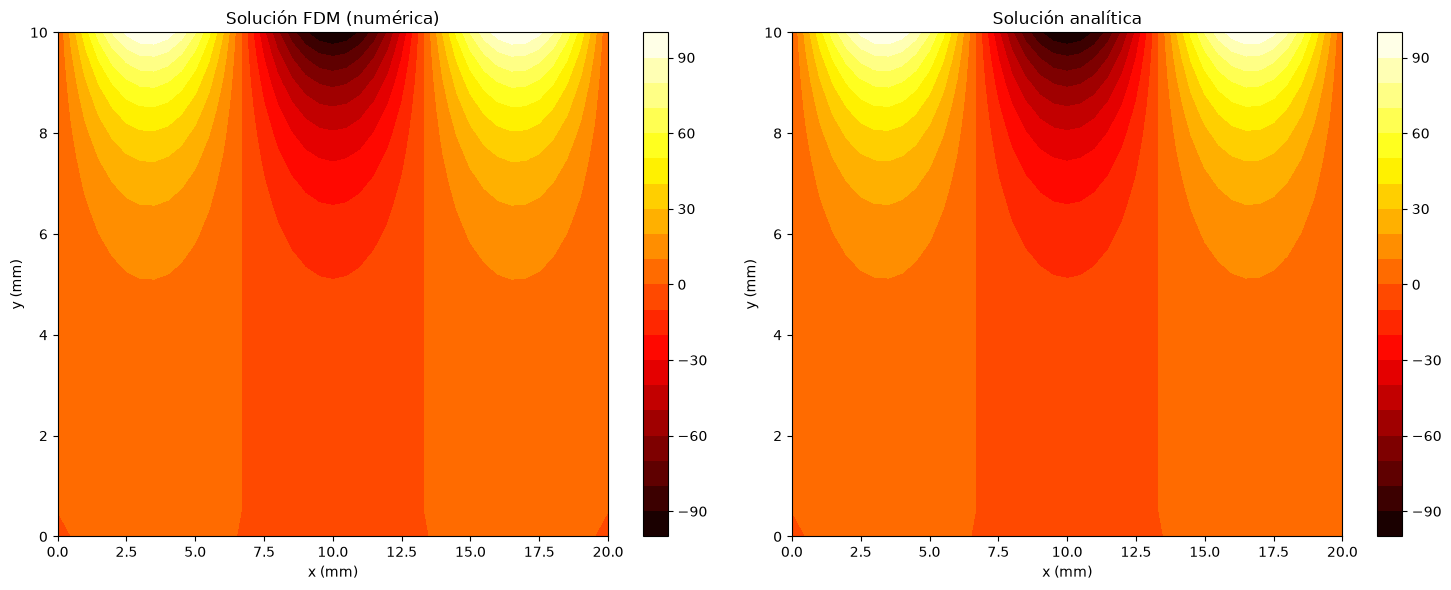

In [ ]:
#2. Solución analítica:
#T(x,y) = 100 * sin(3*pi*x/a) * sinh(3*pi*y/a) / sinh(3*pi*b/a)

n_modo = 3
T_analytic = 100 * np.sin(n_modo * np.pi * X / a) * \
             np.sinh(n_modo * np.pi * Y / a) / np.sinh(n_modo * np.pi * b / a)

diferencia = np.abs(T_static - T_analytic)
print(f"[Parte 2] Diferencia maxima FDM vs analitica = {np.max(diferencia):.4f} C")

# Grafica comparativa
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

im0 = axs[0].contourf(X, Y, T_static, 20, cmap='hot')
axs[0].set_title('Solución FDM (numérica)')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].contourf(X, Y, T_analytic, 20, cmap='hot')
axs[1].set_title('Solución analítica')
plt.colorbar(im1, ax=axs[1])

for ax in axs:
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')

plt.tight_layout()

[Parte 3] Diferencia final con el estado estacionario = 5.7399 C
Temperatura mínima: -100.0 °C
Temperatura máxima: 99.6917333733128 °C


Text(0, 0.5, 'y (mm)')

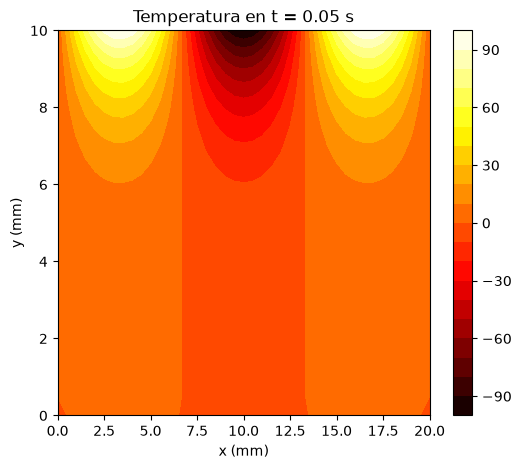

In [34]:
#3. Solución dependiente del tiempo (ecuación de difusión)

dt_max = dx**2*dy**2/(2*D*(dx**2+dy**2))
dt = 0.5*dt_max   # tomamos un poco menos que el maximo, por seguridad

T = np.zeros((ny,nx))
T[-1, :] = f(x)
T[0, :] = 0.0
T[:, 0] = 0.0
T[:, -1] = 0.0

t_final = 0.05
n_steps = int(t_final/dt)

for step in range(n_steps):
    T_new = T.copy()
    T_new[1:-1, 1:-1] = T[1:-1, 1:-1] + D * dt * (
        (T[1:-1, 2:] - 2 * T[1:-1, 1:-1] + T[1:-1, :-2]) / dx**2 +
        (T[2:, 1:-1] - 2 * T[1:-1, 1:-1] + T[:-2, 1:-1]) / dy**2
    )
    T_new[-1, :] = f(x)
    T_new[0, :] = 0.0
    T_new[:, 0] = 0.0
    T_new[:, -1] = 0.0
    T = T_new

print(f"[Parte 3] Diferencia final con el estado estacionario = "
      f"{np.max(np.abs(T - T_static)):.4f} C")

print("Temperatura mínima:", np.min(T), "°C")
print("Temperatura máxima:", np.max(T), "°C")

#Gráfica temperatura al final de la simulación
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(X, Y, T, 20, cmap='hot', vmin=-100, vmax=100)
plt.colorbar(im, ax=ax)
ax.set_title(f'Temperatura en t = {t_final} s')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')